In [1]:
import sys
import sqlite3 as sql
import pandas as pd
import numpy as np

In [2]:
from pathlib import Path

current_dir = Path.cwd().resolve()

# Handle notebook execution from either the repo root or the notebooks folder.
if current_dir.name == "notebooks":
    project_root = current_dir.parent
else:
    project_root = current_dir

raw_path = project_root / "data" / "raw" / "Messy_Employee_dataset.csv"

print("Current working directory:", current_dir)
print("Project root:", project_root)
print("Raw data path:", raw_path)
print("File exists:", raw_path.exists())


Current working directory: C:\Users\Alchemy\Documents\[A] Projects\employee_analytics\employee-workforce-analytics\notebooks
Project root: C:\Users\Alchemy\Documents\[A] Projects\employee_analytics\employee-workforce-analytics
Raw data path: C:\Users\Alchemy\Documents\[A] Projects\employee_analytics\employee-workforce-analytics\data\raw\Messy_Employee_dataset.csv
File exists: True


In [3]:
# Import the raw data into a pandas dataframe
raw_df = pd.read_csv(
    raw_path,
    dtype=str,
    keep_default_na=False
)

# Check the rows and columns of the dataframe
print("Rows:", raw_df.shape[0])
print("Columns:", raw_df.shape[1])

Rows: 1020
Columns: 12


In [4]:
# Check the column names

print("Columns:")
print(raw_df.columns.tolist())

raw_df.head()

Columns:
['Employee_ID', 'First_Name', 'Last_Name', 'Age', 'Department_Region', 'Status', 'Join_Date', 'Salary', 'Email', 'Phone', 'Performance_Score', 'Remote_Work']


,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25,DevOps-California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,TRUE
1,EMP1001,Bob,Brown,,Finance-Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,TRUE
2,EMP1002,Alice,Jones,,Admin-Nevada,Pending,12/7/2023,88145.9,alice.jones@example.com,-5596363211,Good,TRUE
3,EMP1003,Eva,Davis,25,Admin-Nevada,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,TRUE
4,EMP1004,Frank,Williams,25,Cloud Tech-Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,FALSE


In [5]:
raw_df.dtypes

Employee_ID          str
First_Name           str
Last_Name            str
Age                  str
Department_Region    str
Status               str
Join_Date            str
Salary               str
Email                str
Phone                str
Performance_Score    str
Remote_Work          str
dtype: object

In [6]:
raw_df.isna().sum()

Employee_ID          0
First_Name           0
Last_Name            0
Age                  0
Department_Region    0
Status               0
Join_Date            0
Salary               0
Email                0
Phone                0
Performance_Score    0
Remote_Work          0
dtype: int64

In [7]:
missing_values = ["", " ", "NA", "N/A", "na", "n/a", "null", "NULL", "none", "None"]

for column in raw_df.columns:
    matches = raw_df[column].isin(missing_values).sum()
    if matches > 0:
        print(f"{column}: {matches}")

Age: 211
Salary: 24


In [8]:
for column in ["Age", "Salary"]:
    print(f"\n{column}")
    print(raw_df[column].value_counts(dropna=False).head(15))


Age
Age
      211
40    210
25    206
30    205
35    188
Name: count, dtype: int64

Salary
Salary
N/A          24
52031.74      2
62603.98      2
100215.06     2
77764.24      2
60687.63      2
69146.95      2
52615.44      2
77821.79      2
115229.12     2
67492.73      2
82547.26      2
63049.22      2
71318.79      2
71148.27      2
Name: count, dtype: int64


In [9]:
working_df = raw_df.copy()

working_df["Age"] = working_df["Age"].replace("", np.nan)
working_df["Salary"] = working_df["Salary"].replace("N/A", np.nan)

working_df[["Age", "Salary"]].isna().sum()

Age       211
Salary     24
dtype: int64

In [10]:
working_df["Age"] = pd.to_numeric(working_df["Age"], errors="coerce")
working_df["Salary"] = pd.to_numeric(working_df["Salary"], errors="coerce")

print(working_df[["Age", "Salary"]].dtypes)
print(working_df[["Age", "Salary"]].isna().sum())

Age       float64
Salary    float64
dtype: object
Age       211
Salary     24
dtype: int64


In [11]:
working_df[["Age", "Salary"]].describe()

,Age,Salary
count,809.000000,996.000000
mean,32.484549,85155.056396
std,5.656860,19873.727918
min,25.000000,50047.320000
25%,25.000000,68392.487500
50%,30.000000,85547.870000
75%,40.000000,100974.027500
max,40.000000,119971.650000


In [12]:
working_df["Age"].value_counts(dropna=False).sort_index()

Age
25.0    206
30.0    205
35.0    188
40.0    210
NaN     211
Name: count, dtype: int64

In [13]:
categorical_columns = [
    "Department_Region",
    "Status",
    "Performance_Score",
    "Remote_Work"
]

for column in categorical_columns:
    print(f"\n{column}")
    print(working_df[column].value_counts(dropna=False))


Department_Region
Department_Region
HR-Florida               41
DevOps-California        35
Sales-Nevada             35
Admin-Nevada             34
Admin-California         34
DevOps-Florida           34
DevOps-New York          33
HR-New York              33
Sales-Florida            33
DevOps-Illinois          33
Finance-Illinois         33
Finance-California       32
Sales-California         31
Sales-Illinois           30
Finance-Texas            29
Admin-Illinois           29
Finance-Nevada           29
Cloud Tech-Texas         29
Cloud Tech-California    29
Cloud Tech-Florida       28
DevOps-Texas             27
DevOps-Nevada            27
Sales-New York           26
HR-California            26
Admin-Florida            25
Cloud Tech-New York      24
Finance-Florida          24
HR-Nevada                24
HR-Illinois              24
Sales-Texas              23
HR-Texas                 23
Finance-New York         23
Admin-Texas              22
Admin-New York           22
Cloud Tech-

In [14]:
duplicate_count = working_df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

working_df[working_df.duplicated(keep=False)].sort_values(
    by=["First_Name", "Last_Name"]
)

Duplicate rows: 0


,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work


In [15]:
print("Unique Employee IDs:", working_df["Employee_ID"].nunique())
print("Total rows:", len(working_df))
print("Duplicate Employee IDs:", working_df["Employee_ID"].duplicated().sum())

Unique Employee IDs: 1020
Total rows: 1020
Duplicate Employee IDs: 0


In [16]:
for column in ["Email", "Phone"]:
    duplicate_count = working_df[column].duplicated(keep=False).sum()
    unique_values = working_df[column].nunique()

    print(f"{column}")
    print("Unique values:", unique_values)
    print("Rows with repeated values:", duplicate_count)
    print()

working_df[
    working_df["Email"].duplicated(keep=False)
].sort_values("Email").head(20)

Email
Unique values: 64
Rows with repeated values: 1020

Phone
Unique values: 1020
Rows with repeated values: 0



,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
16,EMP1016,Alice,Brown,25.0,DevOps-Illinois,Inactive,4/23/2024,94867.33,alice.brown@example.com,-7713334475,Poor,FALSE
29,EMP1029,Alice,Brown,40.0,DevOps-California,Active,5/24/2021,63411.31,alice.brown@example.com,-2849939088,Excellent,TRUE
36,EMP1036,Alice,Brown,NaN,Cloud Tech-New York,Active,5/3/2023,54757.26,alice.brown@example.com,-2515837766,Poor,FALSE
45,EMP1045,Alice,Brown,25.0,HR-New York,Pending,6/20/2021,61310.74,alice.brown@example.com,-61027768,Average,TRUE
53,EMP1053,Alice,Brown,30.0,Finance-California,Inactive,11/5/2024,54859.45,alice.brown@example.com,-8146717956,Average,FALSE
103,EMP1103,Alice,Brown,30.0,Admin-Illinois,Inactive,6/23/2020,119574.27,alice.brown@example.com,-3985547434,Average,TRUE
163,EMP1163,Alice,Brown,NaN,HR-Florida,Pending,3/4/2020,54257.78,alice.brown@example.com,-7546926328,Poor,TRUE
235,EMP1235,Alice,Brown,NaN,Admin-Nevada,Inactive,1/29/2022,76040.94,alice.brown@example.com,-7189813128,Good,TRUE
312,EMP1312,Alice,Brown,35.0,DevOps-Nevada,Inactive,5/28/2024,86712.41,alice.brown@example.com,-6501917919,Average,TRUE
427,EMP1427,Alice,Brown,35.0,Cloud Tech-Nevada,Inactive,10/4/2024,101665.79,alice.brown@example.com,-3110291812,Poor,TRUE


In [17]:
working_df["Email"].value_counts().head(10)

Email
grace.brown@example.com      27
frank.smith@example.com      25
grace.smith@example.com      23
charlie.jones@example.com    22
frank.brown@example.com      22
eva.davis@example.com        21
david.johnson@example.com    21
eva.miller@example.com       21
eva.jones@example.com        21
bob.jones@example.com        20
Name: count, dtype: int64

In [18]:
sample_email = working_df["Email"].value_counts().index[0]

working_df[
    working_df["Email"] == sample_email
][
    ["Employee_ID", "First_Name", "Last_Name", "Email", "Phone"]
].head(20)

,Employee_ID,First_Name,Last_Name,Email,Phone
66,EMP1066,Grace,Brown,grace.brown@example.com,-7850720810
77,EMP1077,Grace,Brown,grace.brown@example.com,-6110627370
79,EMP1079,Grace,Brown,grace.brown@example.com,-6776228276
88,EMP1088,Grace,Brown,grace.brown@example.com,-4818139889
129,EMP1129,Grace,Brown,grace.brown@example.com,-9594652169
204,EMP1204,Grace,Brown,grace.brown@example.com,-7912141613
231,EMP1231,Grace,Brown,grace.brown@example.com,-1764750110
233,EMP1233,Grace,Brown,grace.brown@example.com,-1926764920
266,EMP1266,Grace,Brown,grace.brown@example.com,-7416787255
339,EMP1339,Grace,Brown,grace.brown@example.com,-7303064420


In [19]:
email_name_counts = (
    working_df
    .groupby("Email")[["First_Name", "Last_Name"]]
    .nunique()
)

email_name_counts.head()

,First_Name,Last_Name
Email,,
alice.brown@example.com,1,1
alice.davis@example.com,1,1
alice.garcia@example.com,1,1
alice.johnson@example.com,1,1
alice.jones@example.com,1,1


In [20]:
multiple_name_emails = (
    (email_name_counts["First_Name"] > 1) |
    (email_name_counts["Last_Name"] > 1)
).sum()

print("Emails linked to multiple names:", multiple_name_emails)

Emails linked to multiple names: 0


In [21]:
email_counts = working_df["Email"].value_counts()
print(email_counts.describe())

largest_email = email_counts.index[0]

working_df[
    working_df["Email"] == largest_email
][
    ["Employee_ID", "First_Name", "Last_Name", "Email", "Phone"]
]

count    64.000000
mean     15.937500
std       4.116845
min       7.000000
25%      13.750000
50%      15.000000
75%      19.000000
max      27.000000
Name: count, dtype: float64


,Employee_ID,First_Name,Last_Name,Email,Phone
66,EMP1066,Grace,Brown,grace.brown@example.com,-7850720810
77,EMP1077,Grace,Brown,grace.brown@example.com,-6110627370
79,EMP1079,Grace,Brown,grace.brown@example.com,-6776228276
88,EMP1088,Grace,Brown,grace.brown@example.com,-4818139889
129,EMP1129,Grace,Brown,grace.brown@example.com,-9594652169
204,EMP1204,Grace,Brown,grace.brown@example.com,-7912141613
231,EMP1231,Grace,Brown,grace.brown@example.com,-1764750110
233,EMP1233,Grace,Brown,grace.brown@example.com,-1926764920
266,EMP1266,Grace,Brown,grace.brown@example.com,-7416787255
339,EMP1339,Grace,Brown,grace.brown@example.com,-7303064420


In [22]:
comparison_columns = [
    "Employee_ID",
    "Phone",
    "Department_Region",
    "Status",
    "Join_Date",
    "Salary",
    "Performance_Score",
    "Remote_Work"
]

working_df[
    working_df["Email"] == largest_email
][comparison_columns]

,Employee_ID,Phone,Department_Region,Status,Join_Date,Salary,Performance_Score,Remote_Work
66,EMP1066,-7850720810,Admin-Nevada,Pending,1/12/2020,112486.19,Excellent,TRUE
77,EMP1077,-6110627370,Finance-New York,Pending,12/29/2022,51887.65,Good,FALSE
79,EMP1079,-6776228276,Admin-Florida,Inactive,11/22/2021,103286.08,Average,FALSE
88,EMP1088,-4818139889,Cloud Tech-Florida,Inactive,7/25/2023,112410.25,Good,TRUE
129,EMP1129,-9594652169,DevOps-Nevada,Active,10/11/2022,117537.71,Excellent,FALSE
204,EMP1204,-7912141613,HR-Texas,Inactive,9/24/2021,62618.40,Excellent,FALSE
231,EMP1231,-1764750110,DevOps-Florida,Inactive,7/4/2022,52964.86,Good,TRUE
233,EMP1233,-1926764920,Sales-Nevada,Pending,11/23/2020,116695.26,Good,FALSE
266,EMP1266,-7416787255,DevOps-California,Pending,11/19/2021,85512.05,Good,FALSE
339,EMP1339,-7303064420,HR-Florida,Pending,10/13/2020,105334.87,Average,FALSE


In [23]:
group_variation = (
    working_df.groupby("Email")[
        ["Phone", "Department_Region", "Status", "Join_Date", "Salary"]
    ]
    .nunique()
)

group_variation.head()

,Phone,Department_Region,Status,Join_Date,Salary
Email,,,,,
alice.brown@example.com,16,15,3,16,15
alice.davis@example.com,15,14,3,15,15
alice.garcia@example.com,17,13,3,17,17
alice.johnson@example.com,15,14,3,14,14
alice.jones@example.com,7,6,2,7,7


In [24]:
(group_variation > 1).sum()

Phone                64
Department_Region    64
Status               64
Join_Date            64
Salary               64
dtype: int64

In [25]:
name_counts = (
    working_df.groupby(["First_Name", "Last_Name"])
    .size()
    .sort_values(ascending=False)
)

name_counts.head(10)

First_Name  Last_Name
Grace       Brown        27
Frank       Smith        25
Grace       Smith        23
Charlie     Jones        22
Frank       Brown        22
David       Johnson      21
Eva         Jones        21
            Miller       21
            Davis        21
            Brown        20
dtype: int64

In [26]:
print("Unique full names:", name_counts.shape[0])

Unique full names: 64


In [27]:
name_email_check = (
    working_df
    .groupby("Email")
    .apply(
        lambda group: group[["First_Name", "Last_Name"]]
        .drop_duplicates()
        .shape[0],
        include_groups=False
    )
)

print("Email groups linked to one full name:", (name_email_check == 1).sum())
print("Email groups linked to multiple full names:", (name_email_check > 1).sum())

Email groups linked to one full name: 64
Email groups linked to multiple full names: 0


In [28]:
join_date_counts = (
    working_df
    .groupby(["First_Name", "Last_Name", "Email"])["Join_Date"]
    .nunique()
)

print(join_date_counts.describe())

count    64.000000
mean     15.843750
std       4.087219
min       7.000000
25%      13.750000
50%      15.000000
75%      18.250000
max      27.000000
Name: Join_Date, dtype: float64


In [29]:
working_df["Department_Region"].value_counts()

Department_Region
HR-Florida               41
DevOps-California        35
Sales-Nevada             35
Admin-Nevada             34
Admin-California         34
DevOps-Florida           34
DevOps-New York          33
HR-New York              33
Sales-Florida            33
DevOps-Illinois          33
Finance-Illinois         33
Finance-California       32
Sales-California         31
Sales-Illinois           30
Finance-Texas            29
Admin-Illinois           29
Finance-Nevada           29
Cloud Tech-Texas         29
Cloud Tech-California    29
Cloud Tech-Florida       28
DevOps-Texas             27
DevOps-Nevada            27
Sales-New York           26
HR-California            26
Admin-Florida            25
Cloud Tech-New York      24
Finance-Florida          24
HR-Nevada                24
HR-Illinois              24
Sales-Texas              23
HR-Texas                 23
Finance-New York         23
Admin-Texas              22
Admin-New York           22
Cloud Tech-Nevada        20
Cl

In [30]:
working_df[["Department", "Region"]] = (
    working_df["Department_Region"]
    .str.split("-", n = 1, expand=True)
)

working_df[["Department_Region", "Department", "Region"]].head()

,Department_Region,Department,Region
0,DevOps-California,DevOps,California
1,Finance-Texas,Finance,Texas
2,Admin-Nevada,Admin,Nevada
3,Admin-Nevada,Admin,Nevada
4,Cloud Tech-Florida,Cloud Tech,Florida


In [31]:
print(working_df["Department"].value_counts())
print()
print(working_df["Region"].value_counts())

Department
DevOps        189
Sales         178
HR            171
Finance       170
Admin         166
Cloud Tech    146
Name: count, dtype: int64

Region
California    187
Florida       185
Nevada        169
Illinois      165
New York      161
Texas         153
Name: count, dtype: int64


In [32]:
print("Missing Department:", working_df["Department"].isna().sum())
print("Missing Region:", working_df["Region"].isna().sum())

reconstructed = working_df["Department"] + "-" + working_df["Region"]

print(
    "Mismatched rows:",
    (reconstructed != working_df["Department_Region"]).sum()
)

Missing Department: 0
Missing Region: 0
Mismatched rows: 0


In [33]:
working_df["Join_Date"] = pd.to_datetime(
    working_df["Join_Date"],
    errors="coerce"
)

print("Invalid dates:", working_df["Join_Date"].isna().sum())
print("Earliest date:", working_df["Join_Date"].min())
print("Latest date:", working_df["Join_Date"].max())

Invalid dates: 0
Earliest date: 2020-01-01 00:00:00
Latest date: 2024-12-29 00:00:00


In [34]:
for column in ["Status", "Performance_Score", "Remote_Work"]:
    print(f"\n{column}")
    print(working_df[column].value_counts(dropna=False))


Status
Status
Pending     356
Active      352
Inactive    312
Name: count, dtype: int64

Performance_Score
Performance_Score
Good         270
Average      267
Excellent    267
Poor         216
Name: count, dtype: int64

Remote_Work
Remote_Work
TRUE     513
FALSE    507
Name: count, dtype: int64


In [35]:
working_df["Remote_Work"] = working_df["Remote_Work"].map({
    "TRUE": True,
    "FALSE": False
})

print(working_df["Remote_Work"].dtype)
print(working_df["Remote_Work"].isna().sum())
print(working_df["Remote_Work"].value_counts())

bool
0
Remote_Work
True     513
False    507
Name: count, dtype: int64


In [36]:
performance_map = {
    "Poor": 1,
    "Average": 2,
    "Good": 3,
    "Excellent": 4
}

working_df["Performance_Score_Ordinal"] = (
    working_df["Performance_Score"].map(performance_map)
)

print(working_df["Performance_Score_Ordinal"].isna().sum())

working_df[
    ["Performance_Score", "Performance_Score_Ordinal"]
].drop_duplicates().sort_values("Performance_Score_Ordinal")

0


,Performance_Score,Performance_Score_Ordinal
4,Poor,1
0,Average,2
2,Good,3
1,Excellent,4


In [37]:
snapshot_date = working_df["Join_Date"].max()

working_df["Tenure_Years"] = (
    (snapshot_date - working_df["Join_Date"]).dt.days / 365.25
)

print("Snapshot date:", snapshot_date)
print(working_df["Tenure_Years"].describe())

Snapshot date: 2024-12-29 00:00:00
count    1020.000000
mean        2.427003
std         1.478460
min         0.000000
25%         1.162218
50%         2.388775
75%         3.714579
max         4.993840
Name: Tenure_Years, dtype: float64


In [38]:
working_df["Join_Year"] = working_df["Join_Date"].dt.year
working_df["Join_Month"] = working_df["Join_Date"].dt.month
working_df["Join_Quarter"] = working_df["Join_Date"].dt.quarter

working_df[
    ["Join_Date", "Join_Year", "Join_Month", "Join_Quarter"]
].head()

,Join_Date,Join_Year,Join_Month,Join_Quarter
0,2021-04-02,2021,4,2
1,2020-07-10,2020,7,3
2,2023-12-07,2023,12,4
3,2021-11-27,2021,11,4
4,2022-01-05,2022,1,1


In [39]:
working_df["Join_Year"].value_counts().sort_index()

Join_Year
2020    203
2021    189
2022    183
2023    228
2024    217
Name: count, dtype: int64

In [40]:
date_feature_errors = (
    (working_df["Join_Year"] != working_df["Join_Date"].dt.year) |
    (working_df["Join_Month"] != working_df["Join_Date"].dt.month) |
    (working_df["Join_Quarter"] != working_df["Join_Date"].dt.quarter)
).sum()

print("Date feature mismatches:", date_feature_errors)

Date feature mismatches: 0


In [41]:
processed_path = project_root / "data" / "interim" / "employee_cleaned_checkpoint.csv"

working_df.to_csv(processed_path, index=False)

print("Saved:", processed_path.exists())
print("Path:", processed_path)

checkpoint_df = pd.read_csv(processed_path)

print("Rows:", checkpoint_df.shape[0])
print("Columns:", checkpoint_df.shape[1])

Saved: True
Path: C:\Users\Alchemy\Documents\[A] Projects\employee_analytics\employee-workforce-analytics\data\interim\employee_cleaned_checkpoint.csv


Rows: 1020
Columns: 19


In [42]:
database_path = project_root / "employee_analytics.db"

connection = sql.connect(database_path)

working_df.to_sql(
    "stg_employee_cleaned",
    connection,
    if_exists="replace",
    index=False
)

print("Database created:", database_path.exists())

query = """
SELECT COUNT(*) AS row_count
FROM stg_employee_cleaned;
"""

pd.read_sql_query(query, connection)

Database created: True


,row_count
0,1020


In [43]:
query = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT employee_id) AS unique_employees,
    SUM(CASE WHEN Age is NULL THEN 1 ELSE 0 END) AS missing_age,
    SUM(CASE WHEN Salary is NULL THEN 1 ELSE 0 END) AS missing_salary
FROM stg_employee_cleaned;
"""

pd.read_sql_query(query, connection)

,total_rows,unique_employees,missing_age,missing_salary
0,1020,1020,211,24


In [44]:
query = """

SELECT
    Department,
    COUNT(*) AS employee_count
FROM stg_employee_cleaned
GROUP BY Department
ORDER BY employee_count DESC;
"""
pd.read_sql_query(query, connection)

,Department,employee_count
0,DevOps,189
1,Sales,178
2,HR,171
3,Finance,170
4,Admin,166
5,Cloud Tech,146


In [ ]:
sql_department_counts = pd.read_sql_query(query, connection)

pandas_department_counts = (
    working_df["Department"]
    .value_counts()
    .rename_axis("Department")
    .reset_index(name="employee_count")
)

sql_department_counts

comparison = sql_department_counts.merge(
    pandas_department_counts,
    on = "Department",
    suffixes = ("_sql", "_pandas")
)

comparison["matched"] = (
    comparison["employee_count_sql"]
    == comparison["employee_count_pandas"]
)

comparison

,Department,employee_count_sql,employee_count_pandas,matched
0,DevOps,189,189,True
1,Sales,178,178,True
2,HR,171,171,True
3,Finance,170,170,True
4,Admin,166,166,True
5,Cloud Tech,146,146,True


In [46]:
query = """
SELECT
    Region,
    COUNT(*) AS employee_count
FROM stg_employee_cleaned
GROUP BY Region
ORDER BY employee_count DESC;
"""

pd.read_sql_query(query, connection)

,Region,employee_count
0,California,187
1,Florida,185
2,Nevada,169
3,Illinois,165
4,New York,161
5,Texas,153


In [47]:
query = """
SELECT
    Department,
    COUNT(*) AS employee_count,
    COUNT(Salary) AS salary_count,
    ROUND(
    100.0 * (COUNT(*) - COUNT(Salary)) / COUNT(*),
    2
) AS missing_salary_pct,
    COUNT(*) - COUNT(Salary) AS missing_salary_count,
    ROUND(AVG(Salary), 2) AS average_salary
FROM stg_employee_cleaned
GROUP BY Department
ORDER BY average_salary DESC;
"""

pd.read_sql_query(query, connection)

,Department,employee_count,salary_count,missing_salary_pct,missing_salary_count,average_salary
0,Sales,178,175,1.69,3,86896.68
1,DevOps,189,184,2.65,5,86016.02
2,HR,171,167,2.34,4,85473.64
3,Admin,166,161,3.01,5,85191.92
4,Cloud Tech,146,141,3.42,5,84923.04
5,Finance,170,168,1.18,2,82240.61


In [48]:
department_salary_summary = pd.read_sql_query(query, connection)

department_salary_summary

print(
    "Total missing salaries:",
    department_salary_summary["missing_salary_count"].sum()
)

Total missing salaries: 24


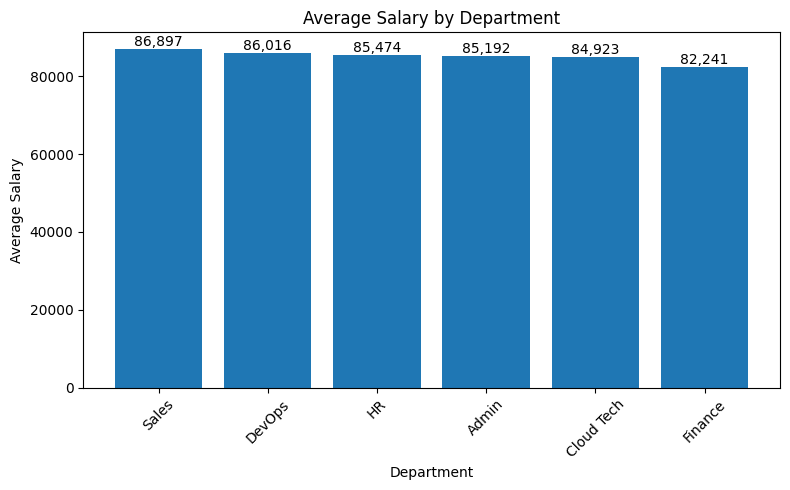

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize = (8, 5))

bars = plt.bar(
    department_salary_summary["Department"],
    department_salary_summary["average_salary"]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha = "center",
        va = "bottom"
    )

plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.grid(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
figure_path = project_root / "reports" / "figures" / "average_salary_by_department.png"

plt.savefig(
    figure_path,
    dpi = 300,
    bbox_inches = "tight"
)

print("Figure saved:", figure_path.exists())
print("Path:", figure_path)

Figure saved: True
Path: C:\Users\Alchemy\Documents\[A] Projects\employee_analytics\employee-workforce-analytics\reports\figures\average_salary_by_department.png


<Figure size 640x480 with 0 Axes>

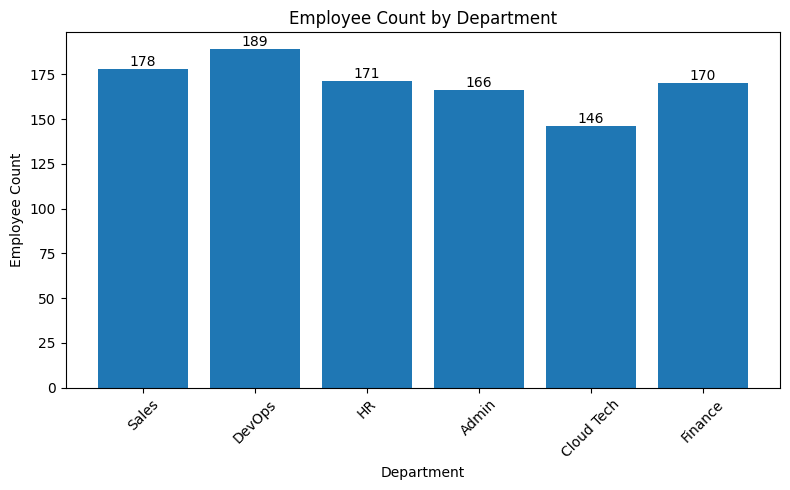

In [ ]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    department_salary_summary["Department"],
    department_salary_summary["employee_count"]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha = "center",
        va = "bottom"
    )

plt.title("Employee Count by Department")
plt.xlabel("Department")
plt.ylabel("Employee Count")
plt.grid(False)
plt.xticks(rotation = 45)
plt.tight_layout()

figure_path = (
    project_root
    / "reports"
    / "figures"
    / "employee_count_by_department.png"
)

plt.savefig(
    figure_path,
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

DevOps department has the largest number of employees, while Sales department has the highest average salary. This shows that department size and average salary do not necessarily move together, although the result is descriptive and does not explain why the difference exists.

In [52]:
region_query = """
SELECT
    Region,
    COUNT(*) AS employee_count
FROM stg_employee_cleaned
GROUP BY Region
ORDER BY employee_count DESC;
"""

region_summary = pd.read_sql_query(region_query, connection)
region_summary

,Region,employee_count
0,California,187
1,Florida,185
2,Nevada,169
3,Illinois,165
4,New York,161
5,Texas,153


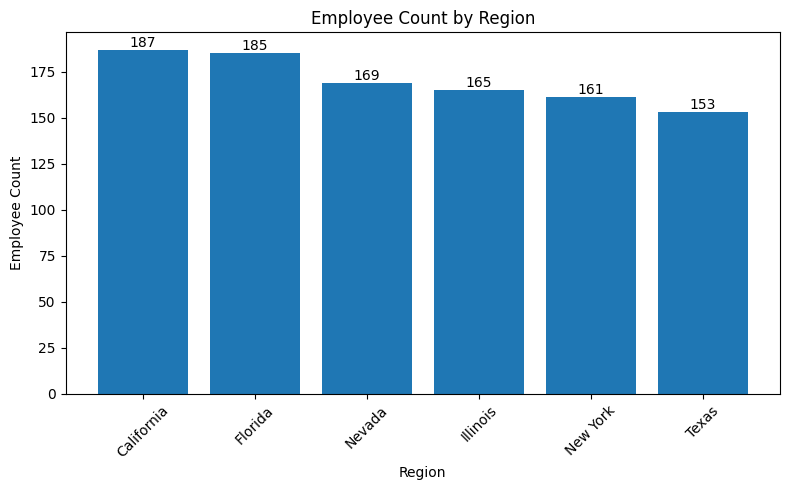

In [ ]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    region_summary["Region"],
    region_summary["employee_count"]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha = "center",
        va = "bottom"
    )

plt.title("Employee Count by Region")
plt.xlabel("Region")
plt.ylabel("Employee Count")
plt.grid(False)
plt.xticks(rotation=45)
plt.tight_layout()

figure_path = (
    project_root
    / "reports"
    / "figures"
    / "employee_count_by_region.png"
)

plt.savefig(
    figure_path,
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

In [55]:
region_summary.iloc[0]

Region            California
employee_count           187
Name: 0, dtype: object

In [58]:
status_query = """
SELECT
    Department,
    Status,
    COUNT(*) AS employee_count
FROM stg_employee_cleaned
GROUP BY Department, Status
ORDER BY Department, employee_count DESC;
"""

status_summary = pd.read_sql_query(status_query, connection)
status_summary

,Department,Status,employee_count
0,Admin,Active,58
1,Admin,Pending,57
2,Admin,Inactive,51
3,Cloud Tech,Pending,59
4,Cloud Tech,Active,45
5,Cloud Tech,Inactive,42
6,DevOps,Active,78
7,DevOps,Inactive,58
8,DevOps,Pending,53
9,Finance,Inactive,62


In [ ]:
status_pivot = status_summary.pivot(
    index = "Department",
    columns = "Status",
    values = "employee_count"
).fillna(0)

status_pivot

Status,Active,Inactive,Pending
Department,,,
Admin,58,51,57
Cloud Tech,45,42,59
DevOps,78,58,53
Finance,49,62,59
HR,57,49,65
Sales,65,50,63


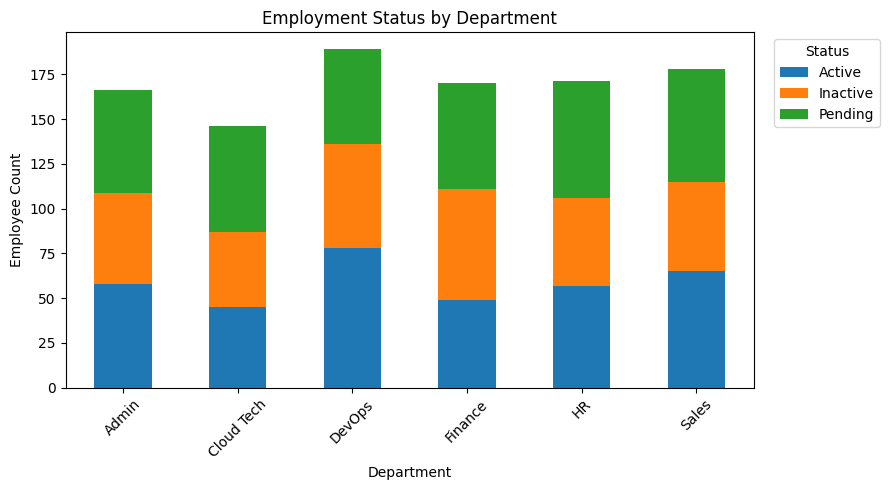

Figure saved: True


<Figure size 640x480 with 0 Axes>

In [73]:
status_pivot.plot(
    kind = "bar",
    stacked = True,
    figsize = (9, 5)
)

plt.title("Employment Status by Department")
plt.xlabel("Department")
plt.ylabel("Employee Count")
plt.grid(False)
plt.xticks(rotation=45)

plt.legend(
    title = "Status",
    bbox_to_anchor = (1.02, 1),
    loc = "upper left"
)

plt.tight_layout()
plt.show()

figure_path = (
    project_root
    / "reports"
    / "figures"
    / "employment_status_by_department.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

print("Figure saved:", figure_path.exists())

In [64]:
working_df["Status"].value_counts()

Status
Pending     356
Active      352
Inactive    312
Name: count, dtype: int64

Pending is the most common employment status with 356 employees, followed closely by Active with 352. The small difference suggests that the workforce is nearly evenly distributed between these two statuses, while Inactive employees form the smallest group.

In [65]:
remote_query = """
SELECT
    Department,
    Remote_Work,
    COUNT(*) AS employee_count
FROM stg_employee_cleaned
GROUP BY Department, Remote_Work
ORDER BY Department, Remote_Work;
"""

remote_summary = pd.read_sql_query(remote_query, connection)
remote_summary

,Department,Remote_Work,employee_count
0,Admin,0,80
1,Admin,1,86
2,Cloud Tech,0,75
3,Cloud Tech,1,71
4,DevOps,0,89
5,DevOps,1,100
6,Finance,0,84
7,Finance,1,86
8,HR,0,91
9,HR,1,80


In [69]:
remote_pivot = remote_summary.pivot(
    index = "Department",
    columns = "Remote_Work",
    values = "employee_count"
).fillna(0)

remote_pct = remote_pivot.div(
    remote_pivot.sum(axis=1),
    axis = 0
) * 100

remote_pct

Remote_Work,0,1
Department,,
Admin,48.192771,51.807229
Cloud Tech,51.369863,48.630137
DevOps,47.089947,52.910053
Finance,49.411765,50.588235
HR,53.216374,46.783626
Sales,49.438202,50.561798


In [68]:
remote_pct.sum(axis = 1)

Department
Admin         100.0
Cloud Tech    100.0
DevOps        100.0
Finance       100.0
HR            100.0
Sales         100.0
dtype: float64

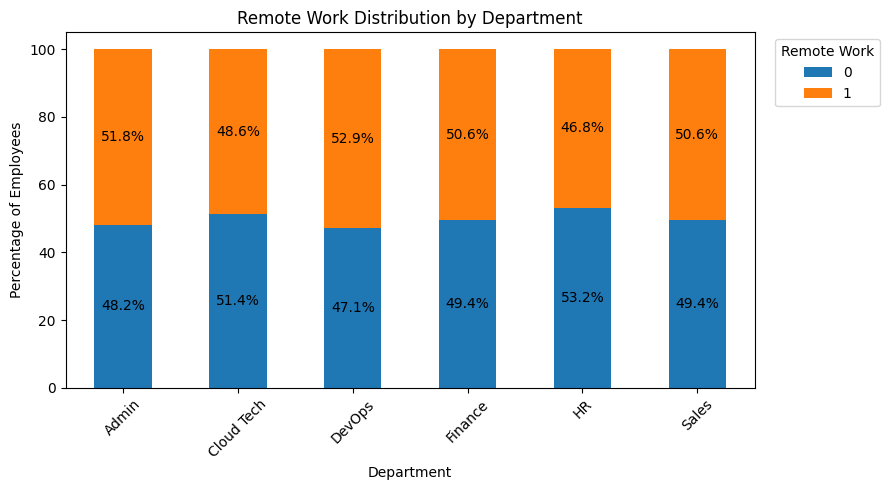

Figure saved: True


In [72]:
ax = remote_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="center"
    )

plt.title("Remote Work Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Percentage of Employees")
plt.grid(False)
plt.xticks(rotation=45)

plt.legend(
    title="Remote Work",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

figure_path = (
    project_root
    / "reports"
    / "figures"
    / "remote_work_distribution_by_department.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", figure_path.exists())

In [80]:
remote_pct[1].sort_values(ascending=False)

Department
DevOps        52.910053
Admin         51.807229
Finance       50.588235
Sales         50.561798
Cloud Tech    48.630137
HR            46.783626
Name: 1, dtype: float64

DevOps has the highest proportion of remote employees at 52.91%, while HR has the lowest at 46.78%. However, the differences across departments are small, with all remote-work shares remaining close to 50%.

In [81]:
remote_salary_query = """
SELECT
    Remote_Work,
    COUNT(Salary) AS salary_count,
    ROUND(AVG(Salary), 2) AS average_salary
FROM stg_employee_cleaned
GROUP BY Remote_Work
ORDER BY Remote_Work;
"""

remote_salary_summary = pd.read_sql_query(
    remote_salary_query,
    connection
)

remote_salary_summary

,Remote_Work,salary_count,average_salary
0,0,495,85842.15
1,1,501,84476.19


In [82]:
85842.15 - 84476.19

1365.9599999999919

Non-remote employees have an average salary of 85,842.15, compared with 84,476.19 for remote employees—a difference of 1,365.96. This is a descriptive comparison only and does not show that remote-work status causes salary differences.

In [85]:
performance_query = """
SELECT
    Department,
    COUNT(Performance_Score_Ordinal) AS score_count,
    ROUND(AVG(Performance_Score_Ordinal), 2) AS average_performance_score
FROM stg_employee_cleaned
GROUP BY Department
ORDER BY average_performance_score DESC;
"""

performance_summary = pd.read_sql_query(
    performance_query,
    connection
)

performance_summary

,Department,score_count,average_performance_score
0,Sales,178,2.66
1,Admin,166,2.63
2,HR,171,2.59
3,Cloud Tech,146,2.56
4,DevOps,189,2.53
5,Finance,170,2.49


In [86]:
performance_summary.iloc[0]

Department                   Sales
score_count                    178
average_performance_score     2.66
Name: 0, dtype: object

Sales has the highest average performance score at 2.66 based on the ordinal scale from 1 to 4. However, the difference should be treated as descriptive because averaging ordinal categories provides only a simplified comparison of performance across departments.

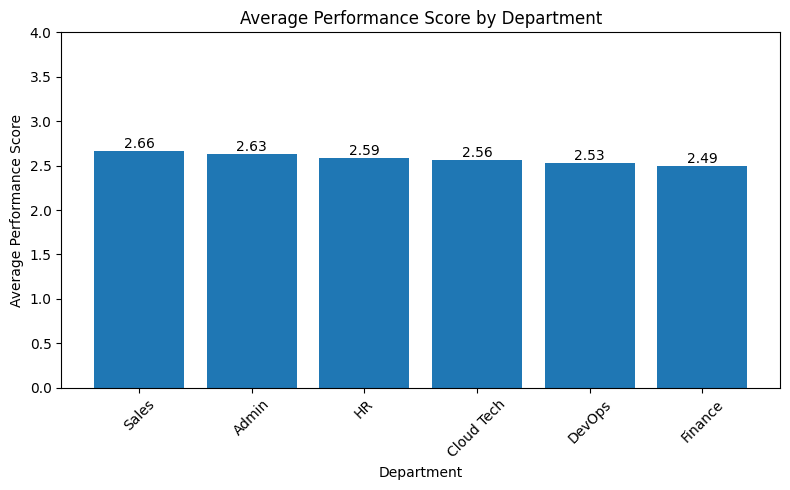

Figure saved: True


In [87]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    performance_summary["Department"],
    performance_summary["average_performance_score"]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.title("Average Performance Score by Department")
plt.xlabel("Department")
plt.ylabel("Average Performance Score")
plt.ylim(0, 4)
plt.grid(False)
plt.xticks(rotation=45)
plt.tight_layout()

figure_path = (
    project_root
    / "reports"
    / "figures"
    / "average_performance_by_department.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", figure_path.exists())

In [88]:
performance_salary_query = """
SELECT
    Performance_Score,
    COUNT(Salary) AS salary_count,
    ROUND(AVG(Salary), 2) AS average_salary
FROM stg_employee_cleaned
GROUP BY Performance_Score
ORDER BY average_salary DESC;
"""

performance_salary_summary = pd.read_sql_query(
    performance_salary_query,
    connection
)

performance_salary_summary

,Performance_Score,salary_count,average_salary
0,Good,260,86338.76
1,Excellent,260,85044.75
2,Poor,213,85035.91
3,Average,263,84190.40


Employees rated Good have the highest average salary at 86,338.76, while those rated Average have the lowest at 84,190.40. The salary pattern does not increase consistently with performance level, so the result should be treated as descriptive rather than evidence that higher performance leads to higher salary.

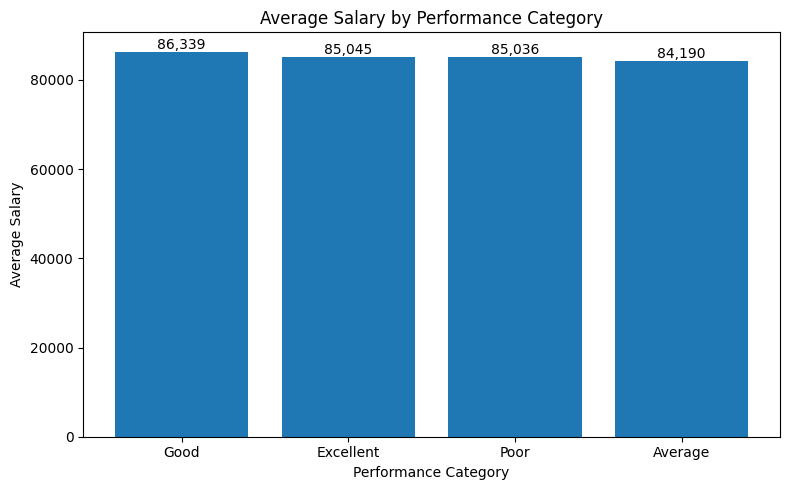

Figure saved: True


In [89]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    performance_salary_summary["Performance_Score"],
    performance_salary_summary["average_salary"]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom"
    )

plt.title("Average Salary by Performance Category")
plt.xlabel("Performance Category")
plt.ylabel("Average Salary")
plt.grid(False)
plt.tight_layout()

figure_path = (
    project_root
    / "reports"
    / "figures"
    / "average_salary_by_performance.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", figure_path.exists())

In [90]:
join_year_query = """
SELECT
    Join_Year,
    COUNT(*) AS employee_count
FROM stg_employee_cleaned
GROUP BY Join_Year
ORDER BY Join_Year;
"""

join_year_summary = pd.read_sql_query(
    join_year_query,
    connection
)

join_year_summary

,Join_Year,employee_count
0,2020,203
1,2021,189
2,2022,183
3,2023,228
4,2024,217


Employee joins declined from 203 in 2020 to 183 in 2022, then increased to a peak of 228 in 2023 before slightly decreasing to 217 in 2024. This suggests hiring activity strengthened after 2022, although the counts reflect join records only and should not be interpreted as net workforce growth.

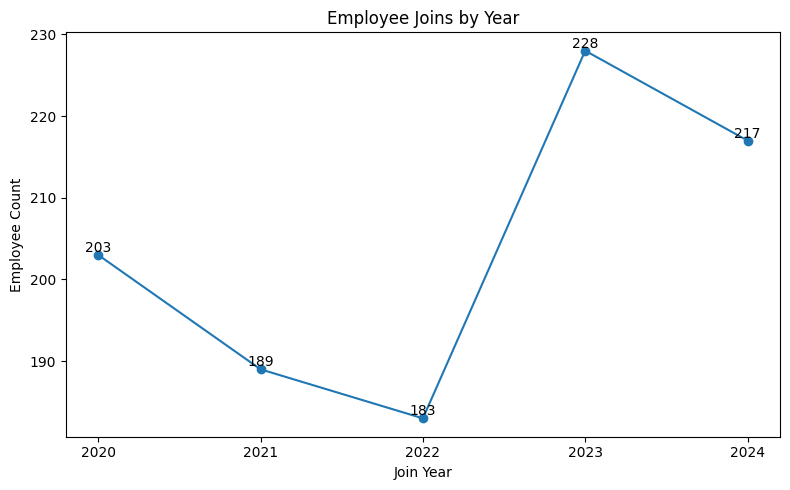

Figure saved: True


In [91]:
plt.figure(figsize=(8, 5))

plt.plot(
    join_year_summary["Join_Year"],
    join_year_summary["employee_count"],
    marker="o"
)

for _, row in join_year_summary.iterrows():
    plt.text(
        row["Join_Year"],
        row["employee_count"],
        str(row["employee_count"]),
        ha="center",
        va="bottom"
    )

plt.title("Employee Joins by Year")
plt.xlabel("Join Year")
plt.ylabel("Employee Count")
plt.xticks(join_year_summary["Join_Year"])
plt.grid(False)
plt.tight_layout()

figure_path = (
    project_root
    / "reports"
    / "figures"
    / "employee_joins_by_year.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", figure_path.exists())

In [92]:
join_department_query = """
SELECT
    Join_Year,
    Department,
    COUNT(*) AS employee_count
FROM stg_employee_cleaned
GROUP BY Join_Year, Department
ORDER BY Join_Year, Department;
"""

join_department_summary = pd.read_sql_query(
    join_department_query,
    connection
)

join_department_summary

,Join_Year,Department,employee_count
0,2020,Admin,32
1,2020,Cloud Tech,34
2,2020,DevOps,36
3,2020,Finance,33
4,2020,HR,34
5,2020,Sales,34
6,2021,Admin,39
7,2021,Cloud Tech,25
8,2021,DevOps,29
9,2021,Finance,32


In [93]:
join_department_pivot = join_department_summary.pivot(
    index="Join_Year",
    columns="Department",
    values="employee_count"
).fillna(0)

join_department_pivot

Department,Admin,Cloud Tech,DevOps,Finance,HR,Sales
Join_Year,,,,,,
2020,32,34,36,33,34,34
2021,39,25,29,32,21,43
2022,32,26,38,30,31,26
2023,36,33,36,40,43,40
2024,27,28,50,35,42,35


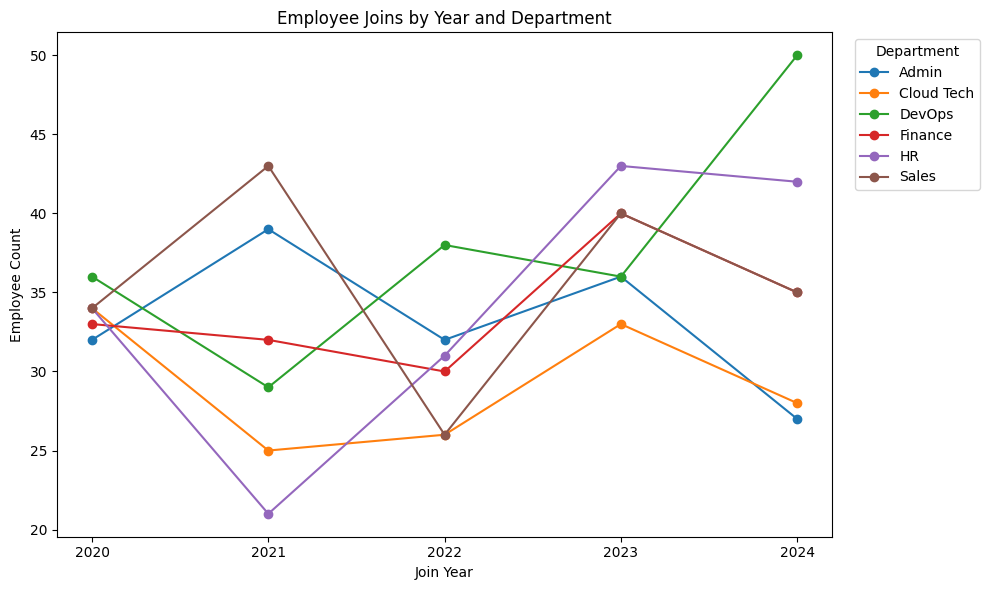

<Figure size 640x480 with 0 Axes>

In [95]:
ax = join_department_pivot.plot(
    kind="line",
    marker="o",
    figsize=(10, 6)
)

plt.title("Employee Joins by Year and Department")
plt.xlabel("Join Year")
plt.ylabel("Employee Count")
plt.xticks(join_department_pivot.index)
plt.grid(False)

plt.legend(
    title="Department",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

figure_path = (
    project_root
    / "reports"
    / "figures"
    / "employee_joins_by_year_and_department.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

In [96]:
top_department_by_year = join_department_pivot.idxmax(axis=1)
top_count_by_year = join_department_pivot.max(axis=1)

pd.DataFrame({
    "top_department": top_department_by_year,
    "employee_count": top_count_by_year
})

,top_department,employee_count
Join_Year,,
2020,DevOps,36
2021,Sales,43
2022,DevOps,38
2023,HR,43
2024,DevOps,50


DevOps recorded the highest employee joins in 2020, 2022, and 2024, while Sales led in 2021 and HR in 2023. This indicates that the department contributing the most new employees varied over time, although DevOps appeared most frequently as the annual leader.

In [97]:
missing_query = """
SELECT
    Department,
    COUNT(*) AS employee_count,
    SUM(CASE WHEN Age IS NULL THEN 1 ELSE 0 END) AS missing_age,
    SUM(CASE WHEN Salary IS NULL THEN 1 ELSE 0 END) AS missing_salary
FROM stg_employee_cleaned
GROUP BY Department
ORDER BY Department;
"""

missing_summary = pd.read_sql_query(
    missing_query,
    connection
)

missing_summary

,Department,employee_count,missing_age,missing_salary
0,Admin,166,37,5
1,Cloud Tech,146,36,5
2,DevOps,189,43,5
3,Finance,170,28,2
4,HR,171,34,4
5,Sales,178,33,3


In [98]:
missing_summary["missing_age_pct"] = (
    missing_summary["missing_age"]
    / missing_summary["employee_count"]
    * 100
).round(2)

missing_summary["missing_salary_pct"] = (
    missing_summary["missing_salary"]
    / missing_summary["employee_count"]
    * 100
).round(2)

missing_summary[
    [
        "Department",
        "missing_age_pct",
        "missing_salary_pct"
    ]
].sort_values("missing_age_pct", ascending=False)

,Department,missing_age_pct,missing_salary_pct
1,Cloud Tech,24.66,3.42
2,DevOps,22.75,2.65
0,Admin,22.29,3.01
4,HR,19.88,2.34
5,Sales,18.54,1.69
3,Finance,16.47,1.18


Cloud Tech has the highest missing-age rate at 24.66%, while Finance has the lowest at 16.47%. Cloud Tech also has the highest missing-salary rate at 3.42%, but salary missingness remains low across all departments.

In [99]:
department_medians = working_df.groupby("Department")[
    ["Age", "Salary"]
].median().round(2)

department_medians

,Age,Salary
Department,,
Admin,30.0,87358.27
Cloud Tech,30.0,86618.37
DevOps,32.5,85837.98
Finance,35.0,83516.34
HR,30.0,85518.88
Sales,30.0,86850.37


In [101]:
working_df["Age_Was_Missing"] = working_df["Age"].isna()
working_df["Salary_Was_Missing"] = working_df["Salary"].isna()

working_df[
    ["Age_Was_Missing", "Salary_Was_Missing"]
].sum()

Age_Was_Missing       211
Salary_Was_Missing     24
dtype: int64

In [102]:
working_df["Salary"] = working_df["Salary"].fillna(
    working_df.groupby("Department")["Salary"].transform("median")
)

print("Missing salary:", working_df["Salary"].isna().sum())
print("Imputed records:", working_df["Salary_Was_Missing"].sum())

Missing salary: 0
Imputed records: 24


In [103]:
working_df["Age"] = working_df["Age"].fillna(
    working_df.groupby("Department")["Age"].transform("median")
)

print("Missing age:", working_df["Age"].isna().sum())
print("Imputed records:", working_df["Age_Was_Missing"].sum())

Missing age: 0
Imputed records: 211


In [104]:
imputed_path = (
    project_root
    / "data"
    / "processed"
    / "employee_imputed.csv"
)

working_df.to_csv(
    imputed_path,
    index=False
)

print("Saved:", imputed_path.exists())
print("Rows:", len(working_df))

Saved: True
Rows: 1020


In [105]:
working_df.to_sql(
    "mart_employee_imputed",
    connection,
    if_exists="replace",
    index=False
)

1020

In [106]:
validation_query = """
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN Age IS NULL THEN 1 ELSE 0 END) AS missing_age,
    SUM(CASE WHEN Salary IS NULL THEN 1 ELSE 0 END) AS missing_salary
FROM mart_employee_imputed;
"""

pd.read_sql_query(validation_query, connection)

,total_rows,missing_age,missing_salary
0,1020,0,0


In [107]:
comparison_query = """
SELECT
    'cleaned' AS dataset,
    COUNT(*) AS total_rows,
    SUM(CASE WHEN Age IS NULL THEN 1 ELSE 0 END) AS missing_age,
    SUM(CASE WHEN Salary IS NULL THEN 1 ELSE 0 END) AS missing_salary
FROM stg_employee_cleaned

UNION ALL

SELECT
    'imputed' AS dataset,
    COUNT(*) AS total_rows,
    SUM(CASE WHEN Age IS NULL THEN 1 ELSE 0 END) AS missing_age,
    SUM(CASE WHEN Salary IS NULL THEN 1 ELSE 0 END) AS missing_salary
FROM mart_employee_imputed;
"""

imputation_comparison = pd.read_sql_query(
    comparison_query,
    connection
)

imputation_comparison

,dataset,total_rows,missing_age,missing_salary
0,cleaned,1020,211,24
1,imputed,1020,0,0


In [109]:
working_df["Attrition_Flag"] = (
    working_df["Status"]
    .eq("Inactive")
    .astype(int)
)

working_df["Attrition_Flag"].value_counts()

Attrition_Flag
0    708
1    312
Name: count, dtype: int64

In [110]:
modeling_columns = [
    "Age",
    "Salary",
    "Department",
    "Region",
    "Remote_Work",
    "Performance_Score_Ordinal",
    "Tenure_Years",
    "Join_Year",
    "Join_Month",
    "Join_Quarter",
    "Age_Was_Missing",
    "Salary_Was_Missing",
    "Attrition_Flag"
]

modeling_df = working_df[modeling_columns].copy()

modeling_df.head()

,Age,Salary,Department,Region,Remote_Work,Performance_Score_Ordinal,Tenure_Years,Join_Year,Join_Month,Join_Quarter,Age_Was_Missing,Salary_Was_Missing,Attrition_Flag
0,25.0,59767.65,DevOps,California,True,2,3.742642,2021,4,2,False,False,0
1,35.0,65304.66,Finance,Texas,True,4,4.470910,2020,7,3,True,False,0
2,30.0,88145.90,Admin,Nevada,True,3,1.062286,2023,12,4,True,False,0
3,25.0,69450.99,Admin,Nevada,True,3,3.088296,2021,11,4,False,False,1
4,25.0,109324.61,Cloud Tech,Florida,False,1,2.981520,2022,1,1,False,False,0


We exclude Status because it was used to create Attrition_Flag; including it would leak the answer into the model. Names, email, phone, and employee ID are also excluded because they are identifiers rather than defensible predictors.

In [ ]:
# Prepare the data for modeling
X = modeling_df.drop(columns = "Attrition_Flag")
y = modeling_df["Attrition_Flag"]

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)
print(y.value_counts(normalize = True).round(3))

Predictor shape: (1020, 12)
Target shape: (1020,)
Attrition_Flag
0    0.694
1    0.306
Name: proportion, dtype: float64


In [116]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = 42,
    stratify=y
)

print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

print("\nTraining target proportion:")
print(y_train.value_counts(normalize = True).round(3))

print("\nTest target proportion:")
print(y_test.value_counts(normalize = True).round(3))

Training set: (816, 12) (816,)
Test set: (204, 12) (204,)

Training target proportion:
Attrition_Flag
0    0.694
1    0.306
Name: proportion, dtype: float64

Test target proportion:
Attrition_Flag
0    0.696
1    0.304
Name: proportion, dtype: float64


In [117]:
# Preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

numeric_features = [
    "Age",
    "Salary",
    "Performance_Score_Ordinal",
    "Tenure_Years",
    "Join_Year",
    "Join_Month",
    "Join_Quarter"
]

categorical_features = [
    "Department",
    "Region",
    "Remote_Work",
    "Age_Was_Missing",
    "Salary_Was_Missing"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [120]:
# Logistic Regression Model
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter = 1000,
                class_weight = "balanced",
                random_state = 42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [121]:
# Predict on the test set
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions:", y_pred.shape)
print("Probabilities:", y_prob.shape)
print("Probability range:", y_prob.min(), "to", y_prob.max())

Predictions: (204,)
Probabilities: (204,)
Probability range: 0.2969879098533945 to 0.7439153359746685


In [122]:
# Evaluate the model
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

ROC-AUC: 0.455

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.57      0.62       142
           1       0.28      0.39      0.33        62

    accuracy                           0.51       204
   macro avg       0.48      0.48      0.47       204
weighted avg       0.56      0.51      0.53       204


Confusion Matrix:
[[81 61]
 [38 24]]


The baseline logistic regression model showed weak predictive performance, with a ROC-AUC of 0.455 and an accuracy of 51%. It correctly identified only 24 of 62 inactive employees, while incorrectly flagging 61 active or pending employees as inactive. These results indicate that the available features contain little reliable signal for predicting employee inactivity, so the model should not be used for operational decisions in its current form.

In [125]:
# Baseline model using DummyClassifier
from sklearn.dummy import DummyClassifier

dummy_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DummyClassifier(strategy="most_frequent")
        )
    ]
)

dummy_model.fit(X_train, y_train)

dummy_pred = dummy_model.predict(X_test)
dummy_prob = dummy_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", round(roc_auc_score(y_test, dummy_prob), 3))

print("\nClassification Report:")
print(classification_report(y_test, dummy_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dummy_pred))

ROC-AUC: 0.5

Classification Report:
              precision    recall  f1-score   support

           0       0.70      1.00      0.82       142
           1       0.00      0.00      0.00        62

    accuracy                           0.70       204
   macro avg       0.35      0.50      0.41       204
weighted avg       0.48      0.70      0.57       204


Confusion Matrix:
[[142   0]
 [ 62   0]]


The majority-class baseline achieved 70% accuracy by predicting every employee as non-inactive. However, it had 0% recall for inactive employees and failed to identify all 62 inactive cases. This confirms that accuracy alone is misleading for this imbalanced classification problem and that recall, F1-score, and ROC-AUC are more informative.

In [126]:
# Compare the models
model_comparison = pd.DataFrame({
    "Model": [
        "Dummy Classifier",
        "Logistic Regression"
    ],
    "Accuracy": [
        0.70,
        0.51
    ],
    "ROC_AUC": [
        0.50,
        0.455
    ],
    "Inactive_Recall": [
        0.00,
        0.39
    ],
    "Inactive_F1": [
        0.00,
        0.33
    ]
})

model_comparison

,Model,Accuracy,ROC_AUC,Inactive_Recall,Inactive_F1
0,Dummy Classifier,0.70,0.500,0.00,0.00
1,Logistic Regression,0.51,0.455,0.39,0.33


In [127]:
comparison_path = (
    project_root
    / "reports"
    / "model_comparison.csv"
)

model_comparison.to_csv(
    comparison_path,
    index=False
)

print("Saved:", comparison_path.exists())

Saved: True


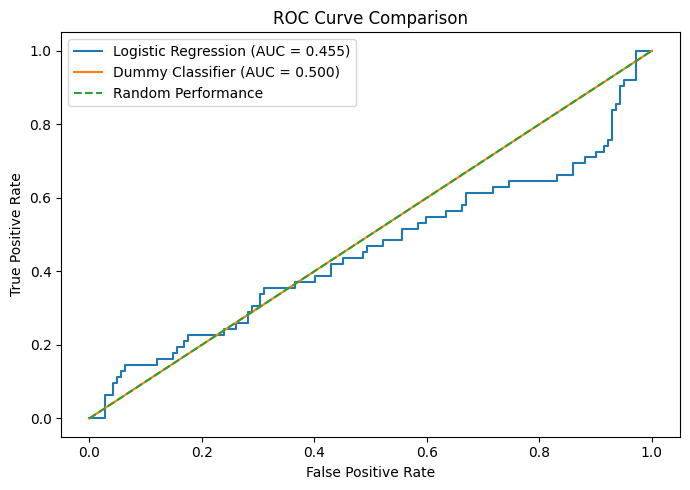

Figure saved: True


In [128]:
# Plot the ROC curves for both models
from sklearn.metrics import roc_curve

log_fpr, log_tpr, _ = roc_curve(y_test, y_prob)
dummy_fpr, dummy_tpr, _ = roc_curve(y_test, dummy_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    log_fpr,
    log_tpr,
    label="Logistic Regression (AUC = 0.455)"
)

plt.plot(
    dummy_fpr,
    dummy_tpr,
    label="Dummy Classifier (AUC = 0.500)"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Performance"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(False)
plt.tight_layout()

figure_path = (
    project_root
    / "reports"
    / "figures"
    / "roc_curve_comparison.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", figure_path.exists())

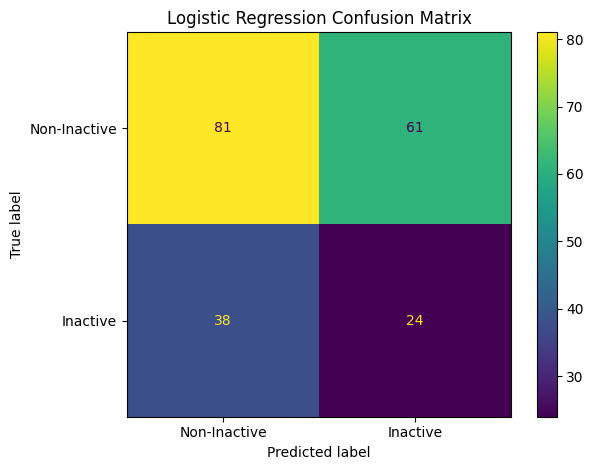

Figure saved: True


In [129]:
# Confusion matrix for the logistic regression model
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Non-Inactive", "Inactive"],
    values_format="d"
)

plt.title("Logistic Regression Confusion Matrix")
plt.grid(False)
plt.tight_layout()

figure_path = (
    project_root
    / "reports"
    / "figures"
    / "logistic_confusion_matrix.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", figure_path.exists())

In [130]:
# Evaluate using Stratiﬁed K-Fold Cross-Validation
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    logistic_model,
    X,
    y,
    cv=cv,
    scoring=[
        "accuracy",
        "roc_auc",
        "precision",
        "recall",
        "f1"
    ]
)

cv_summary = pd.DataFrame(cv_results).filter(like="test_")

cv_summary.agg(["mean", "std"]).round(3)

,test_accuracy,test_roc_auc,test_precision,test_recall,test_f1
mean,0.531,0.502,0.313,0.436,0.364
std,0.052,0.055,0.056,0.055,0.056


Five-fold stratified cross-validation produced a mean ROC-AUC of 0.502, indicating performance equivalent to random ranking. Mean inactive-class recall was 0.436 and mean F1-score was 0.364, with limited variation across folds. This confirms that the weak holdout result was not caused by a single unfavorable train-test split and that the available variables provide insufficient predictive signal for employee inactivity.

In [131]:
cv_output = cv_summary.copy()
cv_output.loc["mean"] = cv_output.mean()
cv_output.loc["std"] = cv_output.iloc[:-1].std()

cv_path = project_root / "reports" / "cross_validation_results.csv"
cv_output.to_csv(cv_path)

print("Saved:", cv_path.exists())

Saved: True


In [133]:
# Test for nonlinearity using Random Forest model
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", round(roc_auc_score(y_test, rf_prob), 3))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

ROC-AUC: 0.447

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.97      0.82       142
           1       0.50      0.06      0.11        62

    accuracy                           0.70       204
   macro avg       0.60      0.52      0.47       204
weighted avg       0.64      0.70      0.60       204


Confusion Matrix:
[[138   4]
 [ 58   4]]


The Random Forest achieved 70% accuracy but a ROC-AUC of only 0.447. It correctly identified just 4 of 62 inactive employees, resulting in an inactive-class recall of 0.06. This shows that the higher accuracy comes mainly from predicting the majority class and that nonlinear modeling did not uncover useful predictive signal.

In [134]:
# Compare the models
model_comparison = pd.DataFrame({
    "Model": [
        "Dummy Classifier",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        0.70,
        0.51,
        0.70
    ],
    "ROC_AUC": [
        0.500,
        0.455,
        0.447
    ],
    "Inactive_Recall": [
        0.00,
        0.39,
        0.06
    ],
    "Inactive_F1": [
        0.00,
        0.33,
        0.11
    ]
})

model_comparison

,Model,Accuracy,ROC_AUC,Inactive_Recall,Inactive_F1
0,Dummy Classifier,0.70,0.500,0.00,0.00
1,Logistic Regression,0.51,0.455,0.39,0.33
2,Random Forest,0.70,0.447,0.06,0.11


In [135]:
model_comparison.to_csv(
    comparison_path,
    index=False
)

print("Updated:", comparison_path.exists())

Updated: True


None of the tested models produced reliable predictive performance. Logistic Regression detected more inactive employees than the other models, but its ROC-AUC remained below 0.50. Random Forest matched the Dummy Classifier's accuracy mainly by favoring the majority class, so no model is suitable for operational attrition prediction using the current dataset.

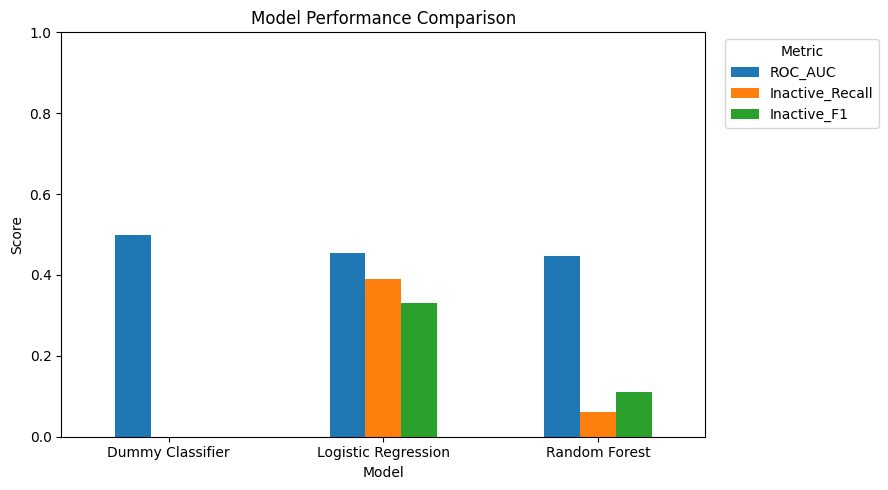

Figure saved: True


In [136]:
# Visualize the model comparison
comparison_plot = model_comparison.set_index("Model")[
    ["ROC_AUC", "Inactive_Recall", "Inactive_F1"]
]

comparison_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(False)
plt.xticks(rotation=0)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

figure_path = (
    project_root
    / "reports"
    / "figures"
    / "model_performance_comparison.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", figure_path.exists())

In [137]:
prediction_results = working_df.loc[
    X_test.index,
    ["Employee_ID", "Department", "Region", "Status"]
].copy()

prediction_results["Actual_Attrition"] = y_test
prediction_results["Predicted_Attrition"] = y_pred
prediction_results["Attrition_Probability"] = y_prob.round(4)

prediction_results.head()

prediction_path = (
    project_root
    / "reports"
    / "logistic_test_predictions.csv"
)

prediction_results.to_csv(
    prediction_path,
    index=False
)

print("Saved:", prediction_path.exists())
print("Rows:", len(prediction_results))

Saved: True
Rows: 204


In [138]:
# Check whether prediction errors are concenctrated in specific departments
prediction_results["Correct_Prediction"] = (
    prediction_results["Actual_Attrition"]
    == prediction_results["Predicted_Attrition"]
)

department_error_summary = (
    prediction_results
    .groupby("Department")
    .agg(
        test_records=("Employee_ID", "count"),
        correct_predictions=("Correct_Prediction", "sum")
    )
)

department_error_summary["accuracy"] = (
    department_error_summary["correct_predictions"]
    / department_error_summary["test_records"]
).round(3)

department_error_summary.sort_values(
    "accuracy",
    ascending=False
)

,test_records,correct_predictions,accuracy
Department,,,
DevOps,40,25,0.625
Sales,39,23,0.590
Admin,35,18,0.514
HR,35,17,0.486
Cloud Tech,24,11,0.458
Finance,31,11,0.355


Logistic Regression performance varied across departments, from 62.5% accuracy in DevOps to 35.5% in Finance. These subgroup results are descriptive because the department test samples are small and accuracy may be influenced by differences in inactive-employee prevalence.

In [139]:
# Calculate the inactive recall by department
from sklearn.metrics import recall_score

department_recall_summary = (
    prediction_results
    .groupby("Department")
    .apply(
        lambda group: recall_score(
            group["Actual_Attrition"],
            group["Predicted_Attrition"],
            zero_division=0
        ),
        include_groups=False
    )
    .rename("inactive_recall")
    .reset_index()
    .sort_values("inactive_recall", ascending=False)
)

department_recall_summary

,Department,inactive_recall
3,Finance,0.700000
0,Admin,0.625000
2,DevOps,0.500000
4,HR,0.333333
5,Sales,0.166667
1,Cloud Tech,0.083333


Finance had the highest inactive recall at 70.0%, while Cloud Tech had the lowest at 8.3%. However, these subgroup results are unstable because each department contains only a small number of inactive test cases, so they should not be interpreted as reliable departmental performance differences.

In [140]:
# Calculate the actual inactive support per department
department_recall_support = (
    prediction_results
    .groupby("Department")
    .agg(
        test_records=("Employee_ID", "count"),
        inactive_cases=("Actual_Attrition", "sum")
    )
    .reset_index()
    .merge(
        department_recall_summary,
        on="Department"
    )
    .sort_values("inactive_recall", ascending=False)
)

department_recall_support

,Department,test_records,inactive_cases,inactive_recall
3,Finance,31,10,0.700000
0,Admin,35,8,0.625000
2,DevOps,40,14,0.500000
4,HR,35,6,0.333333
5,Sales,39,12,0.166667
1,Cloud Tech,24,12,0.083333


Department-level inactive recall ranged from 8.3% in Cloud Tech to 70.0% in Finance. However, each department contained only 6 to 14 inactive test cases, so a difference of only a few predictions can substantially change the recall rate. These subgroup results are therefore diagnostic rather than reliable evidence of department-specific model performance.

In [141]:
subgroup_path = (
    project_root
    / "reports"
    / "department_recall_summary.csv"
)

department_recall_support.to_csv(
    subgroup_path,
    index=False
)

print("Saved:", subgroup_path.exists())

Saved: True


In [142]:
final_modeling_path = (
    project_root
    / "data"
    / "processed"
    / "employee_modeling_dataset.csv"
)

modeling_df.to_csv(
    final_modeling_path,
    index=False
)

print("Saved:", final_modeling_path.exists())
print("Rows:", len(modeling_df))
print("Columns:", len(modeling_df.columns))

Saved: True
Rows: 1020
Columns: 13


In [143]:
print("Duplicate rows:", modeling_df.duplicated().sum())
print("Missing values:", modeling_df.isna().sum().sum())
print("Target values:", sorted(modeling_df["Attrition_Flag"].unique()))

Duplicate rows: 3
Missing values: 0
Target values: [np.int64(0), np.int64(1)]


In [144]:
duplicate_rows = modeling_df[
    modeling_df.duplicated(keep=False)
].sort_values(
    modeling_columns
)

duplicate_rows

,Age,Salary,Department,Region,Remote_Work,Performance_Score_Ordinal,Tenure_Years,Join_Year,Join_Month,Join_Quarter,Age_Was_Missing,Salary_Was_Missing,Attrition_Flag
411,25.0,60687.63,DevOps,Illinois,False,4,1.541410,2023,6,2,False,False,0
1004,25.0,60687.63,DevOps,Illinois,False,4,1.541410,2023,6,2,False,False,0
938,30.0,51990.98,Finance,Nevada,True,4,3.622177,2021,5,2,False,False,0
1014,30.0,51990.98,Finance,Nevada,True,4,3.622177,2021,5,2,False,False,0
626,30.0,77821.79,HR,Illinois,False,2,1.180014,2023,10,4,True,False,1
1006,30.0,77821.79,HR,Illinois,False,2,1.180014,2023,10,4,True,False,1


In [146]:
duplicate_target_check[
    duplicate_target_check["target_count"] > 1
]

,Age,Salary,Department,Region,Remote_Work,Performance_Score_Ordinal,Tenure_Years,Join_Year,Join_Month,Join_Quarter,Age_Was_Missing,Salary_Was_Missing,target_count


Three duplicate rows were found in the modeling feature set after identifiers were removed. Inspection showed that each duplicate profile had the same attrition target, so the records were retained as distinct employee observations rather than treated as data-entry duplicates.

In [148]:
modeling_df.to_sql(
    "mart_employee_modeling",
    connection,
    if_exists="replace",
    index=False
)

sql_check = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT Attrition_Flag) AS target_classes
FROM mart_employee_modeling;
"""

pd.read_sql_query(sql_check, connection)

,total_rows,target_classes
0,1020,2


In [149]:
dashboard_kpis = pd.DataFrame({
    "Metric": [
        "Total Employees",
        "Inactive Employees",
        "Inactive Rate",
        "Average Salary",
        "Remote Work Rate"
    ],
    "Value": [
        len(working_df),
        int(working_df["Attrition_Flag"].sum()),
        round(working_df["Attrition_Flag"].mean() * 100, 2),
        round(working_df["Salary"].mean(), 2),
        round(working_df["Remote_Work"].mean() * 100, 2)
    ]
})

dashboard_kpis

,Metric,Value
0,Total Employees,1020.00
1,Inactive Employees,312.00
2,Inactive Rate,30.59
3,Average Salary,85179.58
4,Remote Work Rate,50.29


In [150]:
kpi_path = (
    project_root
    / "reports"
    / "dashboard_kpis.csv"
)

dashboard_kpis.to_csv(
    kpi_path,
    index=False
)

print("Saved:", kpi_path.exists())

Saved: True


In [151]:
dashboard_kpis.to_sql(
    "mart_dashboard_kpis",
    connection,
    if_exists="replace",
    index=False
)

5

In [152]:
pd.read_sql_query(
    "SELECT * FROM mart_dashboard_kpis;",
    connection
)

,Metric,Value
0,Total Employees,1020.00
1,Inactive Employees,312.00
2,Inactive Rate,30.59
3,Average Salary,85179.58
4,Remote Work Rate,50.29


In [153]:
dashboard_department = (
    working_df
    .groupby("Department")
    .agg(
        employee_count=("Employee_ID", "count"),
        inactive_count=("Attrition_Flag", "sum"),
        average_salary=("Salary", "mean"),
        remote_work_rate=("Remote_Work", "mean"),
        average_performance=("Performance_Score_Ordinal", "mean")
    )
    .reset_index()
)

dashboard_department["inactive_rate"] = (
    dashboard_department["inactive_count"]
    / dashboard_department["employee_count"]
    * 100
)

dashboard_department["remote_work_rate"] *= 100

dashboard_department[
    [
        "average_salary",
        "inactive_rate",
        "remote_work_rate",
        "average_performance"
    ]
] = dashboard_department[
    [
        "average_salary",
        "inactive_rate",
        "remote_work_rate",
        "average_performance"
    ]
].round(2)

dashboard_department

,Department,employee_count,inactive_count,average_salary,remote_work_rate,average_performance,inactive_rate
0,Admin,166,51,85257.17,51.81,2.63,30.72
1,Cloud Tech,146,42,84981.10,48.63,2.56,28.77
2,DevOps,189,58,86011.31,52.91,2.53,30.69
3,Finance,170,62,82255.62,50.59,2.49,36.47
4,HR,171,49,85474.70,46.78,2.59,28.65
5,Sales,178,50,86895.90,50.56,2.66,28.09


In [154]:
department_dashboard_path = (
    project_root
    / "reports"
    / "dashboard_department.csv"
)

dashboard_department.to_csv(
    department_dashboard_path,
    index=False
)

print("Saved:", department_dashboard_path.exists())

Saved: True


In [155]:
dashboard_department.to_sql(
    "mart_dashboard_department",
    connection,
    if_exists="replace",
    index=False
)

pd.read_sql_query(
    "SELECT * FROM mart_dashboard_department;",
    connection
)

,Department,employee_count,inactive_count,average_salary,remote_work_rate,average_performance,inactive_rate
0,Admin,166,51,85257.17,51.81,2.63,30.72
1,Cloud Tech,146,42,84981.10,48.63,2.56,28.77
2,DevOps,189,58,86011.31,52.91,2.53,30.69
3,Finance,170,62,82255.62,50.59,2.49,36.47
4,HR,171,49,85474.70,46.78,2.59,28.65
5,Sales,178,50,86895.90,50.56,2.66,28.09


In [156]:
dashboard_region = (
    working_df
    .groupby("Region")
    .agg(
        employee_count=("Employee_ID", "count"),
        inactive_count=("Attrition_Flag", "sum"),
        average_salary=("Salary", "mean"),
        remote_work_rate=("Remote_Work", "mean")
    )
    .reset_index()
)

dashboard_region["inactive_rate"] = (
    dashboard_region["inactive_count"]
    / dashboard_region["employee_count"]
    * 100
)

dashboard_region["remote_work_rate"] *= 100

dashboard_region[
    ["average_salary", "inactive_rate", "remote_work_rate"]
] = dashboard_region[
    ["average_salary", "inactive_rate", "remote_work_rate"]
].round(2)

dashboard_region

,Region,employee_count,inactive_count,average_salary,remote_work_rate,inactive_rate
0,California,187,53,86635.49,47.59,28.34
1,Florida,185,67,86304.46,51.89,36.22
2,Illinois,165,50,85291.89,53.33,30.30
3,Nevada,169,59,83642.48,57.40,34.91
4,New York,161,38,83826.49,44.10,23.60
5,Texas,153,45,85040.53,47.06,29.41


In [158]:
region_dashboard_path = (
    project_root
    / "reports"
    / "dashboard_region.csv"
)

dashboard_region.to_csv(
    region_dashboard_path,
    index=False
)

print("Saved:", region_dashboard_path.exists())

dashboard_region.to_sql(
    "mart_dashboard_region",
    connection,
    if_exists="replace",
    index=False
)

Saved: True


6

In [159]:
dashboard_year = (
    working_df
    .groupby("Join_Year")
    .agg(
        employee_count=("Employee_ID", "count"),
        inactive_count=("Attrition_Flag", "sum"),
        average_salary=("Salary", "mean")
    )
    .reset_index()
)

dashboard_year["inactive_rate"] = (
    dashboard_year["inactive_count"]
    / dashboard_year["employee_count"]
    * 100
)

dashboard_year[
    ["average_salary", "inactive_rate"]
] = dashboard_year[
    ["average_salary", "inactive_rate"]
].round(2)

dashboard_year

,Join_Year,employee_count,inactive_count,average_salary,inactive_rate
0,2020,203,65,85707.48,32.02
1,2021,189,59,85606.35,31.22
2,2022,183,54,85313.30,29.51
3,2023,228,71,83390.44,31.14
4,2024,217,63,86081.10,29.03


In [160]:
year_dashboard_path = (
    project_root
    / "reports"
    / "dashboard_year.csv"
)

dashboard_year.to_csv(
    year_dashboard_path,
    index=False
)

print("Saved:", year_dashboard_path.exists())

dashboard_year.to_sql(
    "mart_dashboard_year",
    connection,
    if_exists="replace",
    index=False
)

Saved: True


5

In [161]:
table_inventory_query = """
SELECT name AS table_name
FROM sqlite_master
WHERE type = 'table'
ORDER BY name;
"""

table_inventory = pd.read_sql_query(
    table_inventory_query,
    connection
)

table_inventory

,table_name
0,mart_dashboard_department
1,mart_dashboard_kpis
2,mart_dashboard_region
3,mart_dashboard_year
4,mart_employee_imputed
5,mart_employee_modeling
6,stg_employee_cleaned


In [162]:
for table_name in table_inventory["table_name"]:
    row_count = pd.read_sql_query(
        f"SELECT COUNT(*) AS row_count FROM {table_name};",
        connection
    ).iloc[0, 0]

    print(f"{table_name}: {row_count} rows")

mart_dashboard_department: 6 rows
mart_dashboard_kpis: 5 rows
mart_dashboard_region: 6 rows
mart_dashboard_year: 5 rows
mart_employee_imputed: 1020 rows
mart_employee_modeling: 1020 rows
stg_employee_cleaned: 1020 rows


In [163]:
connection.close()
print("Database connection closed.")

Database connection closed.


The project produced validated staging, imputed, modeling, and dashboard-ready tables in SQLite. However, the tested classification models did not demonstrate reliable predictive performance, so the analytical outputs should be used for descriptive workforce reporting rather than operational attrition prediction.

The project successfully transformed a messy employee dataset into validated analytical, modeling, and dashboard-ready outputs using Pandas, SQL, and reproducible preprocessing pipelines. Descriptive analysis revealed workforce differences across departments, regions, work arrangements, performance categories, and join years. However, Logistic Regression and Random Forest did not outperform the baseline reliably, with cross-validated ROC-AUC remaining near 0.50. Therefore, the current dataset is suitable for descriptive workforce analytics but does not contain sufficient signal for defensible attrition prediction.